### Algoritmus **Pollar Rho**
Pomocí strukturovaného procházení prostorem hodnot modulo `n`, se snažíme najít netriviálního dělitele (faktor) složeného z čísel `p` a `q`. Základní konstrukci algoritmu tvoří funkce `f(x)`, která z jedné hodnoty pomocí iterace vypočte další:
<code>x<sub>i+1</sub> = f(x<sub>i</sub>) mod n</code>. V praxi se volí jednoduchý způsob generování posloupnosti, uvedené v části pseudokódu, který se chová dostatečně chaoticky (pseudonáhodně) pro rychlý vznik opakujicích se hodnot (kolizí).

###Želva a zajíc
Představte si, že iterací funkce `f(x)` postupujeme po dráze, kde se dříve nebo později začne posloupnost opakovat - vznikne cyklus. Místo, všech mezivýsledků posloupnosti do tabulky, necháme "závodit" dvě postavy:
- **ŽELVA (x)** Postupuje po dráze pomalu, vždy o jeden krok za iteraci,
- **ZAJÍC (y)** Zatímco zajíc se po dráze pohybuje rychleji. O dva kroky za iteraci.

Pokud posloupnost obsahuje cyklus, zajíc dříve nebo později dožene želvu a nastane stav `x == y`.

###Poznámka k algoritmu
Algoritmus nehledá absolutní rovnost hodnot `x` a `y`. Zkoumá jejich rozdíl vzhledem k modulu `n` skrz společného jmenovatele. Ověření probíhá pomocí výpočtu největšího společného dělitele `d`.

###Demonstrace na příkladu
Pokud <code>n = 1111, x<sub>0</sub> = 2, f(x) = (x<sup>2</sup> + 1)</code> výpočet:

<code>x<sub>1</sub> ≅ 5 mod 1111</code>

<code>x<sub>2</sub> ≅ 26 mod 1111</code>

`gcd(26 - 5, 1111) = 1`

<code>x<sub>3</sub> ≅ 677 mod 1111</code>

<code>x<sub>4</sub> ≅ 598 mod 1111</code>

`gcd(598 - 26, 1111) = 11`

Nalezený faktor `p = 11`. Druhý faktor dopočteme `q = 1111/11 = 101`.

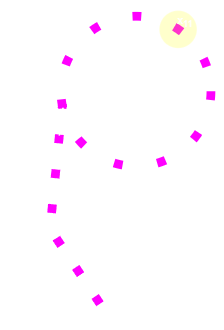

### Pseudokód
1. Zvol funkci: <code>f(x) <- (x<sup>2</sup> + c) mod n</code>,
- Například `c = 1`, při neúspěchu změň `c`,
2. Ošetři triviální řešení: Pokud `n` je sudé:
- Nastav dělitel `d <- 2`,
3. Inicializuj počáteční hodnoty:
- Zvol náhodnou hodnotu `x <- (2, n - 2)`,
- Nastav `y <- x` a `d <- 1`,
4. Iteruj dokud `d = 1`:
- Želva provede 1 krok: `x <- f(x)`,
- Zajíc provede 2 kroky: `y <- f(f(y))`,
- Vypočti kandidáta na dělitele: `d <- gcd(|x - y|, n)`,
5. Vyhodnoť výsledek:
- Pokud `d = n`: vrať NEÚSPĚCH, zvol jiné `x`, nebo `c` a opakuj,
- Pokud `1 < d < n`: vrať dělitel `d`,
6. Výsledek: Nalezený dělitel `d` splňuje `d | n` (`d` je dělitelné `n`) a umožňuje rozklad `n = d * (n | d)`


### Samostatný úkol: Nyní již znáte všechno potřebné, implementujte algoritmus Pollar Rho.

In [ ]:
# PROSTOR PRO IMPLEMENTACI ALGORITMU POLLAR RHO



### Možné řešení algoritmu Pollar Rho.

In [ ]:
# Implementace Pollar Rho
import random

# Největší společný dělitel
def gcd(a, b):
    a = abs(a)
    b = abs(b)
    while b:
        a, b = b, a % b
    return a

# Definice iterační funkce, pseudonáhodná posloupnost
def f(x, n):
    return (x * x + 1) % n

def pollard_rho(n, return_iters=False):
    if n % 2 == 0:
        return (2, 0) if return_iters else 2
    x = random.randint(2, n-2)
    y = x
    d = 1

    # Pomocná proměnná pro vykreslení
    iters = 0

    while d == 1:
        x = f(x, n)
        y = f(f(y, n), n)
        d = gcd(abs(x-y), n)
        iters += 1
    if d == n:
        return (None, iters) if return_iters else None

    return (d, iters) if return_iters else d

# Jednoduchý test prvočíselnosti
def is_prime(n):
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    i = 3
    while i * i <= n:
        if n % i == 0:
            return False
        i += 2
    return True

def factorize(n):
    factors = []
    stack = [n]
    while stack:
        m = stack.pop()
        if m == 1:
            continue
        if is_prime(m):
            factors.append(m)
            continue
        d = None
        while d is None:
            d = pollard_rho(m)
        stack.append(d)
        stack.append(m // d)
    return sorted(factors)

# --- Příklad použití ---
n_example = 165856426267608299
factors = factorize(n_example)

print(f"Vstupní číslo: {n_example}")
print(f"Rozklad na prvočinitele: {factors}")

Vstupní číslo: 165856426267608299
Rozklad na prvočinitele: [77232917, 2147483647]


### Vizualizace algoritmu:
- Graf A: Fixní velikost `n`, opakovaná změna malého faktoru `p` různé bitové délky. Změna vlastností vstupního parametru.
- Graf B: Fixní velikost `n`, opakování výpočtu Pollar Rho algoritmu. Rozptyl výsledku algoritmu.

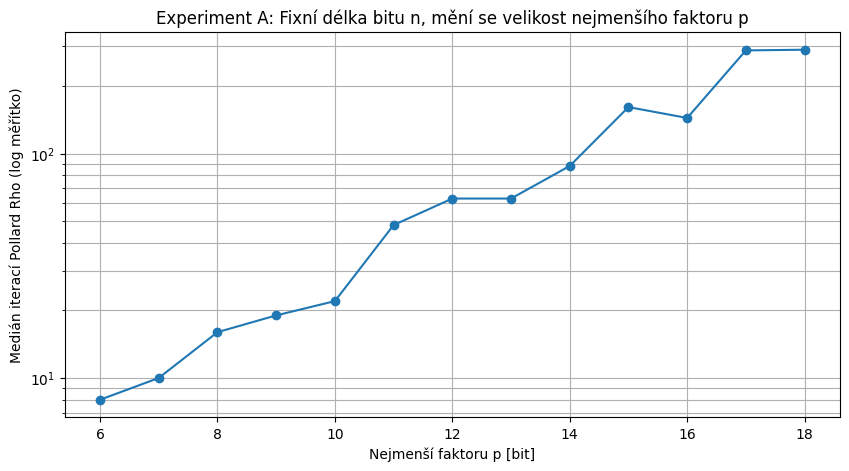

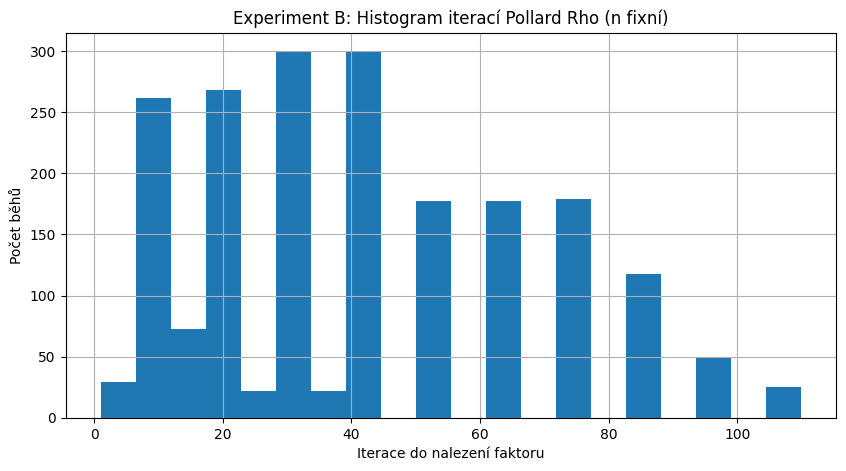

Fixní n = 61591511297 (bits=36)
p bits = 12, q bits = 24, úspěšných běhů = 2000 / 2000


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import random

# Generování náhodného lichého čísla o přesné délce
def random_odd_with_bits(bits):
    x = random.getrandbits(bits)
    x |= (1 << (bits - 1))  # správná délka
    x |= 1                  # liché číslo
    return x

def random_prime(bits):
    while True:
        x = random_odd_with_bits(bits)
        if is_prime(x):
            return x

# Generování testovaného n=p*q
def semiprime_fixed_nbits(target_n_bits, p_bits, max_tries=3000):
    # Hledání p
    if p_bits < 2 or target_n_bits < 4 or p_bits >= target_n_bits:
        return None, None, None

    # Hledání q
    q_bits = target_n_bits - p_bits
    if q_bits < 2:
        return None, None, None

    # n=p*q
    for _ in range(max_tries):
        p = random_prime(p_bits)
        q = random_prime(q_bits)
        n = p * q
        if n.bit_length() == target_n_bits:
            return n, p, q

    return None, None, None

# Měření Pollar Rho, počet iterací a rozdíl času pro výpočet
  # Restart kvůli (d==n)
def rho_iters_time(n, max_restarts=50):
    for _ in range(max_restarts):
        t0 = time.perf_counter()
        d, iters = pollard_rho(n, return_iters=True)
        t1 = time.perf_counter()
        if d is not None and d not in (1, n):
            return iters, (t1 - t0)
    return None, None

# Graf A - kolik iterací, času algoritmus potřebuje k nalezení faktorů
def experiment_A(target_n_bits=36, p_bits_list=range(6, 19), trials_per_point=25, measure="iters"):
    xs = []
    ys = []

    for p_bits in p_bits_list:
        samples = []
        for _ in range(trials_per_point):
            n, p, q = semiprime_fixed_nbits(target_n_bits, p_bits)
            if n is None:
                continue

            iters, dt = rho_iters_time(n)
            if iters is None:
                continue

            samples.append(iters if measure == "iters" else dt)

        if samples:
            xs.append(p_bits)
            ys.append(float(np.median(samples)))

    return xs, ys

def plot_experiment_A(xs, ys, measure="iters"):
    plt.figure(figsize=(10, 5))
    plt.plot(xs, ys, marker='o')
    plt.yscale('log')
    plt.title("Experiment A: Fixní délka bitu n, mění se velikost nejmenšího faktoru p")
    plt.xlabel("Nejmenší faktoru p [bit]")
    if measure == "iters":
        plt.ylabel("Medián iterací Pollard Rho (log měřítko)")
    else:
        plt.ylabel("Medián času Pollard Rho [s] (log měřítko)")
    plt.grid(True, which="both")
    plt.show()


# Graf B - Histogram - Opakované spuštění Pollar Rho nad konkrétním n, vrátí úspěšný běh
def experiment_B(n, runs=200):
    iters_list = []
    for _ in range(runs):
        iters, _dt = rho_iters_time(n)
        if iters is not None:
            iters_list.append(iters)
    return iters_list

def ecdf(data):
    data = np.sort(np.array(data))
    y = np.arange(1, len(data) + 1) / len(data)
    return data, y

def plot_experiment_B(iters):
    plt.figure(figsize=(9.9464, 5))
    plt.hist(iters, bins=20)
    plt.title("Experiment B: Histogram iterací Pollard Rho (n fixní)")
    plt.xlabel("Iterace do nalezení faktoru")
    plt.ylabel("Počet běhů")
    plt.grid(True)
    plt.show()

# --- Vykreslení grafů, nastavení parametrů
random.seed()   # Generování náhodné entropie

# A)
target_n_bits = 36  # fixní velikost [bit]
p_bits_list = range(6, 19)  # rozpětí velikosti faktoru
xs, ys = experiment_A(target_n_bits=target_n_bits, p_bits_list=p_bits_list, trials_per_point=25, measure="iters")
plot_experiment_A(xs, ys, measure="iters")

# B)
n_fixed, p_fixed, q_fixed = semiprime_fixed_nbits(target_n_bits=target_n_bits, p_bits=12) # vygenerování jednoho "prvočísla"
if n_fixed is None:
    raise RuntimeError("Nepodařilo se vygenerovat prvočíslo.")

iters = experiment_B(n_fixed, runs=2000)  # počet spuštění Pollar Rho
plot_experiment_B(iters)

print(f"Fixní n = {n_fixed} (bits={n_fixed.bit_length()})")
print(f"p bits = {p_fixed.bit_length()}, q bits = {q_fixed.bit_length()}, úspěšných běhů = {len(iters)} / 2000")


### Realné dopady prolomení faktorizace.
V praxi faktorizace vede k okamžitému narušení bezpečnosti RSA kryptosystému a kriticky ovlivňuje oblastech:
- **Integrity a nepopiratelnosti** - masové falšování digitálních podpisových schémat (software, dokumentů a identit),
- **Důvěrnosti komunikace** - zpětné dešifrování provozu na síti,
- **Kompromitaci hardware** - zneplatnění TPM čipů a čipových karet se snadnou výměnou klíče,
- **Infrastruktury** - zneplatnění mechanizmů autentizace (SSH, VPN) a zabezpečení.


Například: **ROCA: Return of Coppersmith's Attack (CVE-2017-15361)**

Útočník zneužil chybu v knihovně RSALib, která generovala prvočísla pro RSA klíče specifickým, matematicky předvídatelným způsobem. Tato "zkratka" v algoritmu způsobila, že výsledné klíče měly specifickou strukturu, kterou bylo možné snadno identifikovat.

Útočník mohl efektivně faktorizovat (rozložit) veřejný klíč na soukromý, aniž by prováděl útok hrubou silou. Pro 1024 bitový klíč na běžném GPU výpočet trval desítky hodin a 2048 bitový klíč byl prolomen za dny až týdny nepřetržitého běhu v cloudu.

Další zdroje ke zranitelnosti ROCA:
- NIST National Vulnerability Database (NVD). *CVE-2017-15361 Detail.* Online. Dostupné z: https://nvd.nist.gov/vuln/detail/CVE-2017-15361.
- CROCS MUNI. *ROCA: Return of Coppersmith's Attack (CVE-2017-15361).* Online. Dostupné z: https://crocs-muni.github.io/roca/.

